# 🧮 Guía de IA Generativa - Embeddings, Tokens y Costes

En este notebook aprenderás:
- ✅ Qué son los embeddings y por qué son cruciales para los LLMs
- ✅ Cómo generar y comparar embeddings con modelos reales
- ✅ Qué son los tokens y cómo calcularlos
- ✅ Cómo funcionan los precios de las APIs de IA
- ✅ Estrategias para optimizar costes

**⚠️ IMPORTANTE - SEGURIDAD:**
- ❌ NUNCA compartas tus API keys en este notebook
- ❌ NO subas este archivo a GitHub si contiene keys
- ✅ Usa variables de entorno o widgets seguros
- ✅ Revoca keys si se exponen accidentalmente

---
**📋 Requisitos previos:**
- Haber completado el Notebook 1 (Introducción a IA Generativa)
- Python 3.8+
- Conexión a internet (para APIs)

# 0. SETUP Y CONTEXTO

## 📚 Instalar Librerías

Instalamos todas las librerías necesarias para trabajar con embeddings, tokenización y visualización.

In [2]:
# 📦 Instalación de dependencias
# Esto puede tardar 1-2 minutos la primera vez

import sys
import subprocess
print("🔧 Instalando paquetes necesarios...")
print("=" * 60)

# Lista de paquetes a instalar con sus descripciones
packages = [
    ("google-genai", "🌟 Cliente de Google para Gemini (GRATIS) - Incluye embeddings"),
    ("requests", "🌐 Para hacer peticiones HTTP a APIs REST"),
    ("ipywidgets", "🎨 Widgets interactivos para inputs y visualización"),
    ("numpy", "🔢 Operaciones numéricas y vectoriales"),
    ("scikit-learn", "📊 Para PCA, métricas y visualización"),
    ("matplotlib", "📈 Gráficos y visualizaciones"),
    ("tiktoken", "🎫 Tokenizador de OpenAI (gratuito, offline)"),
    ("sentence-transformers", "🤗 Modelos de embeddings open source (HuggingFace)"),
]

for package, descripcion in packages:
    try:
        print(f"📥 Instalando {package}...")
        print(f"   ℹ️  {descripcion}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✅ {package} instalado correctamente")
    except Exception as e:
        print(f"⚠️ Error instalando {package}: {e}")

print("=" * 60)
print("✨ ¡Instalación completada! Ejecuta la siguiente celda.")

🔧 Instalando paquetes necesarios...
📥 Instalando google-genai...
   ℹ️  🌟 Cliente de Google para Gemini (GRATIS) - Incluye embeddings
✅ google-genai instalado correctamente
📥 Instalando requests...
   ℹ️  🌐 Para hacer peticiones HTTP a APIs REST
✅ requests instalado correctamente
📥 Instalando ipywidgets...
   ℹ️  🎨 Widgets interactivos para inputs y visualización
✅ ipywidgets instalado correctamente
📥 Instalando numpy...
   ℹ️  🔢 Operaciones numéricas y vectoriales
✅ numpy instalado correctamente
📥 Instalando scikit-learn...
   ℹ️  📊 Para PCA, métricas y visualización
✅ scikit-learn instalado correctamente
📥 Instalando matplotlib...
   ℹ️  📈 Gráficos y visualizaciones
✅ matplotlib instalado correctamente
📥 Instalando tiktoken...
   ℹ️  🎫 Tokenizador de OpenAI (gratuito, offline)
✅ tiktoken instalado correctamente
📥 Instalando sentence-transformers...
   ℹ️  🤗 Modelos de embeddings open source (HuggingFace)
✅ sentence-transformers instalado correctamente
✨ ¡Instalación completada! Ejecu

## 📚 Importar Librerías

In [4]:
# Importaciones estándar
import os
import sys
import json
import time
from datetime import datetime
from typing import List, Dict, Optional

# Librerías numéricas y científicas
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Visualización
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML
import ipywidgets as widgets
from ipywidgets import Layout, Button, Box, VBox, HBox, Text, Textarea, Password

# Tokenización (offline, gratuito)
try:
    import tiktoken
    TIKTOKEN_AVAILABLE = True
except ImportError:
    TIKTOKEN_AVAILABLE = False
    print("⚠️ tiktoken no disponible")

# Embeddings locales (HuggingFace - GRATIS)
try:
    from sentence_transformers import SentenceTransformer
    SENTENCE_TRANSFORMERS_AVAILABLE = True
except ImportError:
    SENTENCE_TRANSFORMERS_AVAILABLE = False
    print("⚠️ sentence-transformers no disponible")

# Google Gemini (GRATIS)
try:
    from google import genai
    GEMINI_AVAILABLE = True
except ImportError:
    GEMINI_AVAILABLE = False
    print("⚠️ Google Gemini no disponible")

# Librerías para APIs
import requests

# --------------------------------------------------
# ⚙️ CONFIGURACIÓN SSL PARA PROXIES
# --------------------------------------------------
VERIFICAR_SSL = True  # Cambia a True si NO estás detrás de un proxy

if not VERIFICAR_SSL:
    import urllib3
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
    print("⚠️ ADVERTENCIA: Verificación SSL desactivada")
    print("   Solo para uso en entornos con proxy")

print("\n" + "=" * 60)
print("✅ Todas las librerías importadas correctamente")
print(f"📊 Python version: {sys.version.split()[0]}")
print(f"🕐 Fecha actual: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🔒 Verificación SSL: {'Activada ✅' if VERIFICAR_SSL else 'Desactivada ⚠️'}")
print(f"🤗 Sentence Transformers: {'Disponible ✅' if SENTENCE_TRANSFORMERS_AVAILABLE else 'No disponible ⚠️'}")
print(f"🎫 Tiktoken: {'Disponible ✅' if TIKTOKEN_AVAILABLE else 'No disponible ⚠️'}")


✅ Todas las librerías importadas correctamente
📊 Python version: 3.12.7
🕐 Fecha actual: 2026-03-06 18:01:12
🔒 Verificación SSL: Activada ✅
🤗 Sentence Transformers: Disponible ✅
🎫 Tiktoken: Disponible ✅


## 🔐 Configuración de API Keys (Opcional)

**💡 NOTA:** La mayoría de este notebook funciona **SIN API key** usando modelos locales.

Solo necesitarás API key si quieres probar los embeddings de Google Gemini en la sección 2.

In [6]:
# 🔐 Widget seguro para API Key (OPCIONAL)
print("🔑 Configuración de API Key (OPCIONAL)")
print("=" * 60)
print("")
print("💡 La mayor parte de este notebook funciona SIN API key")
print("   usando modelos locales de HuggingFace.")
print("")
print("🛡️ Si introduces una key:")
print("  - Se guarda SOLO EN MEMORIA (os.environ)")
print("  - NO se guarda en el archivo .ipynb")
print("")

gemini_key_widget = Password(
    placeholder='AIza... (opcional)',
    description='Gemini:',
    disabled=False,
    layout=Layout(width='500px')
)

save_button = Button(
    description='💾 Guardar Key',
    button_style='success',
    layout=Layout(width='200px')
)

status_output = widgets.Output()

def save_keys(b):
    with status_output:
        status_output.clear_output()
        if gemini_key_widget.value and gemini_key_widget.value.startswith('AIza'):
            os.environ['GEMINI_API_KEY'] = gemini_key_widget.value
            print("✅ Key de Gemini guardada en memoria")
        else:
            print("ℹ️ Sin API key - Usaremos modelos locales gratuitos")

save_button.on_click(save_keys)

display(VBox([
    widgets.HTML("<h3>🔐 API Key de Gemini (OPCIONAL):</h3>"),
    widgets.HTML("<p style='color: #666;'>Obténla en: <a href='https://makersuite.google.com/app/apikey' target='_blank'>makersuite.google.com</a></p>"),
    gemini_key_widget,
    save_button,
    status_output
]))

print("\n💡 TIP: Puedes continuar sin key. Los ejercicios principales funcionan con modelos locales.")

🔑 Configuración de API Key (OPCIONAL)

💡 La mayor parte de este notebook funciona SIN API key
   usando modelos locales de HuggingFace.

🛡️ Si introduces una key:
  - Se guarda SOLO EN MEMORIA (os.environ)
  - NO se guarda en el archivo .ipynb




💡 TIP: Puedes continuar sin key. Los ejercicios principales funcionan con modelos locales.


## 📝 Recordatorio del Notebook 1

En el notebook anterior aprendimos:

| Concepto | Descripción |
|----------|-------------|
| **IA Generativa** | IA que crea contenido nuevo (texto, imágenes, etc.) |
| **LLM** | Large Language Model - Modelos grandes de lenguaje |
| **Prompt** | La instrucción que le damos al modelo |
| **API** | Forma programática de comunicarse con los modelos |
| **Transformers** | Arquitectura base de los modelos modernos |

### 🎯 Objetivos de este Notebook

Hoy profundizaremos en **3 conceptos clave** que apenas mencionamos:

1. **Embeddings** 🧮 - Cómo los modelos "entienden" el significado
2. **Tokens** 🎫 - La unidad de medida de los LLMs
3. **Costes** 💰 - Cómo calcular y optimizar gastos

---
# ⭐ 1. EMBEDDINGS: El idioma secreto de los LLMs

## 1.0 ¿Por qué los LLMs necesitan embeddings?

Los ordenadores no entienden palabras, solo números. Entonces... **¿cómo puede un LLM "entender" que "perro" y "can" significan lo mismo?**

### 🧠 El Problema

```
Humano ve:     "gato"  →  🐱 (concepto mental)
Ordenador ve:  "gato"  →  [103, 97, 116, 111] (códigos ASCII)
```

Con ASCII, el ordenador solo ve letras sueltas. **No sabe que "gato" se parece a "felino"**.

### 💡 La Solución: Embeddings

Un **embedding** es un vector numérico que captura el **significado** de una palabra o frase.

```
"gato"   →  [0.23, -0.45, 0.87, 0.12, ...] (768 números)
"felino" →  [0.25, -0.43, 0.85, 0.14, ...] (¡muy similar!)
"coche"  →  [-0.67, 0.91, -0.23, 0.56, ...] (muy diferente)
```

### 🎯 ¿Por qué funciona?

Los embeddings se entrenan con millones de textos. El modelo aprende que:
- Palabras que aparecen en **contextos similares** → vectores similares
- "El **gato** duerme en el sofá" / "El **felino** duerme en el sofá"

### 📊 Analogía Visual

Imagina que cada palabra es un punto en un mapa:

```
        Norte ↑ (animales)
               |
    🐱 gato    |     🐕 perro
        felino |          can
               |
 ←─────────────┼─────────────→
  Oeste        |        Este
 (pequeño)     |      (grande)
               |
        🚗 coche
          auto |
               ↓ Sur (vehículos)
```

**Palabras con significado similar** están **cerca** en el espacio vectorial.

## 1.1 Tu primer embedding (demo interactiva con modelo local)

Vamos a generar embeddings reales usando un modelo **gratuito y local** de HuggingFace.

Este modelo (`all-MiniLM-L6-v2`) es pequeño pero muy efectivo:
- ✅ **100% gratuito** - Se ejecuta en tu ordenador
- ✅ **Sin API key** - No necesita conexión tras la primera descarga
- ✅ **Rápido** - Genera embeddings en milisegundos
- ✅ **Multilingüe** - Funciona con español e inglés

In [7]:
# 🤗 Cargar modelo de embeddings local (GRATIS)
# La primera vez descarga ~80MB, luego es instantáneo

print("🔄 Cargando modelo de embeddings local...")
print("   (Primera vez: descarga ~80MB, luego es instantáneo)")
print("")

if SENTENCE_TRANSFORMERS_AVAILABLE:
    # Usar modelo multilingüe para mejor soporte español
    modelo_embeddings = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    print("✅ Modelo cargado: paraphrase-multilingual-MiniLM-L12-v2")
    print(f"📐 Dimensión de embeddings: {modelo_embeddings.get_sentence_embedding_dimension()}")
else:
    print("❌ sentence-transformers no disponible")
    print("   Ejecuta: pip install sentence-transformers")

🔄 Cargando modelo de embeddings local...
   (Primera vez: descarga ~80MB, luego es instantáneo)



modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Modelo cargado: paraphrase-multilingual-MiniLM-L12-v2
📐 Dimensión de embeddings: 384


In [8]:
# 🎯 Tu primer embedding

# Vamos a convertir una palabra en un vector numérico
palabra = "gato"

# Generar el embedding
embedding_gato = modelo_embeddings.encode(palabra)

print(f"🐱 Palabra: '{palabra}'")
print("")
print("📊 Su embedding (primeros 20 valores de 384):")
print(f"   {embedding_gato[:20].round(3)}")
print("")
print(f"📐 Dimensión total: {len(embedding_gato)} números")
print(f"📈 Valor mínimo: {embedding_gato.min():.4f}")
print(f"📈 Valor máximo: {embedding_gato.max():.4f}")
print(f"📈 Valor medio: {embedding_gato.mean():.4f}")

🐱 Palabra: 'gato'

📊 Su embedding (primeros 20 valores de 384):
   [ 0.477 -0.293  0.006  0.453 -0.317 -0.074  0.531  0.208 -0.009  0.14
  0.121 -0.38  -0.012  0.167 -0.259 -0.401  0.258 -0.717 -0.023  0.16 ]

📐 Dimensión total: 384 números
📈 Valor mínimo: -0.7977
📈 Valor máximo: 1.3288
📈 Valor medio: 0.0007


In [9]:
# 🔍 Comparemos embeddings de palabras similares y diferentes

palabras = ["gato", "felino", "perro", "coche", "automóvil", "programación"]

print("🔄 Generando embeddings para múltiples palabras...")
print("")

embeddings_dict = {}
for palabra in palabras:
    embedding = modelo_embeddings.encode(palabra)
    embeddings_dict[palabra] = embedding
    print(f"✅ '{palabra}' → vector de {len(embedding)} dimensiones")

print("")
print("💡 Ahora tenemos cada palabra representada como un vector de 384 números.")
print("   Podemos comparar palabras midiendo la distancia entre sus vectores.")

🔄 Generando embeddings para múltiples palabras...

✅ 'gato' → vector de 384 dimensiones
✅ 'felino' → vector de 384 dimensiones
✅ 'perro' → vector de 384 dimensiones
✅ 'coche' → vector de 384 dimensiones
✅ 'automóvil' → vector de 384 dimensiones
✅ 'programación' → vector de 384 dimensiones

💡 Ahora tenemos cada palabra representada como un vector de 384 números.
   Podemos comparar palabras midiendo la distancia entre sus vectores.


## 1.2 Analogía visual: mapa semántico 2D

Los embeddings tienen muchas dimensiones (384 en nuestro modelo), pero podemos **proyectarlos a 2D** para visualizarlos.

Usamos una técnica llamada **PCA** (Principal Component Analysis) para reducir dimensiones.

C:\Users\fbata\AppData\Local\Temp\ipykernel_2596\4067472962.py:48: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fbata\AppData\Local\Temp\ipykernel_2596\4067472962.py:48: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fbata\AppData\Local\Temp\ipykernel_2596\4067472962.py:48: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fbata\AppData\Local\Temp\ipykernel_2596\4067472962.py:48: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fbata\AppData\Local\Temp\ipykernel_2596\4067472962.py:48: UserWarning: Glyph 127829 (\N{SLICE OF PIZZA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fbata\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu S

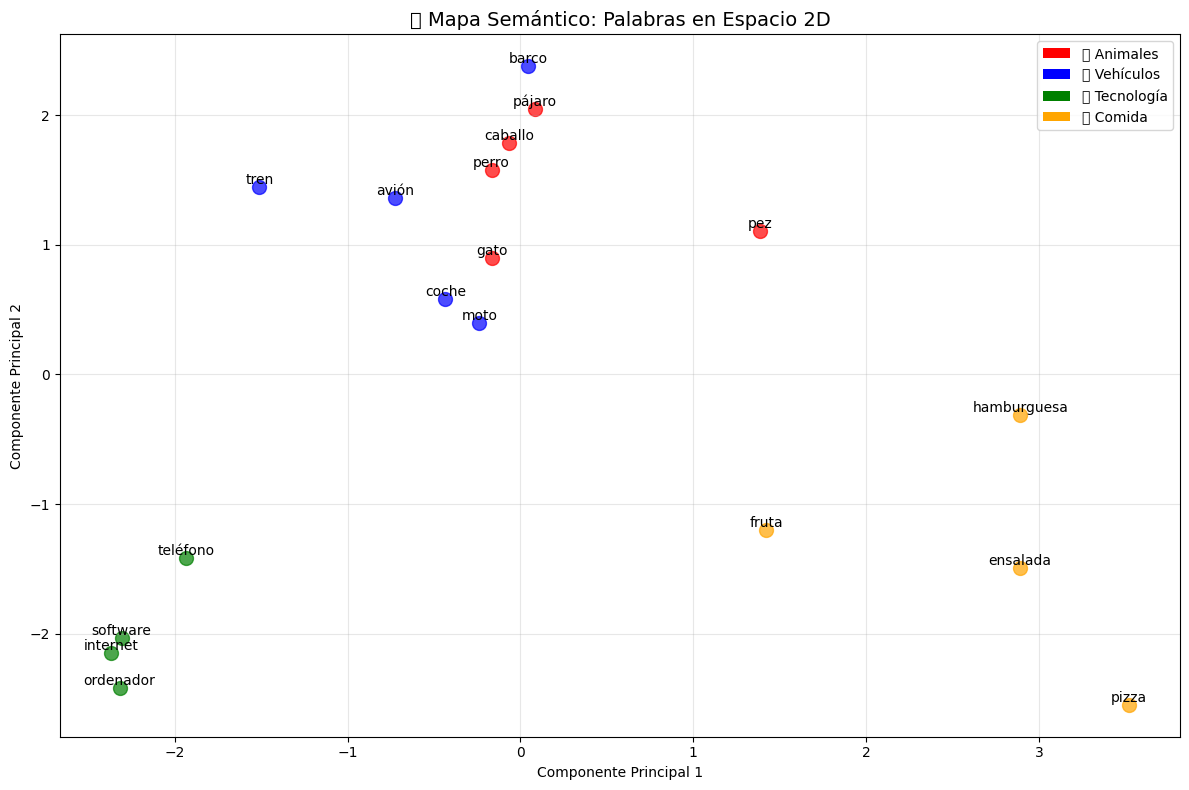


💡 OBSERVA: Las palabras de la misma categoría tienden a estar juntas.
   Esto es porque los embeddings capturan el SIGNIFICADO, no solo las letras.


In [10]:
# 🗺️ Visualización: Mapa semántico 2D

# Añadimos más palabras para ver patrones interesantes
palabras_viz = [
    # Animales
    "gato", "perro", "pájaro", "pez", "caballo",
    # Vehículos
    "coche", "moto", "avión", "barco", "tren",
    # Tecnología
    "ordenador", "teléfono", "internet", "software",
    # Comida
    "pizza", "hamburguesa", "ensalada", "fruta"
]

# Generar embeddings
embeddings_viz = modelo_embeddings.encode(palabras_viz)

# Reducir a 2D con PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_viz)

# Crear gráfico
plt.figure(figsize=(12, 8))

# Colores por categoría
colores = ['red']*5 + ['blue']*5 + ['green']*4 + ['orange']*4
categorias = ['Animales']*5 + ['Vehículos']*5 + ['Tecnología']*4 + ['Comida']*4

# Scatter plot
for i, (palabra, pos) in enumerate(zip(palabras_viz, embeddings_2d)):
    plt.scatter(pos[0], pos[1], c=colores[i], s=100, alpha=0.7)
    plt.annotate(palabra, (pos[0], pos[1]), fontsize=10, ha='center', va='bottom')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='🐾 Animales'),
    Patch(facecolor='blue', label='🚗 Vehículos'),
    Patch(facecolor='green', label='💻 Tecnología'),
    Patch(facecolor='orange', label='🍕 Comida')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.title('🗺️ Mapa Semántico: Palabras en Espacio 2D', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 OBSERVA: Las palabras de la misma categoría tienden a estar juntas.")
print("   Esto es porque los embeddings capturan el SIGNIFICADO, no solo las letras.")

## 1.3 Ejercicio: predice similitudes

Antes de calcular las similitudes reales, **intenta predecir** cuáles de estos pares serán más similares:

| Par | Tu predicción (1-10) |
|-----|---------------------|
| "rey" - "reina" | ¿? |
| "rey" - "presidente" | ¿? |
| "rey" - "pizza" | ¿? |
| "Madrid" - "España" | ¿? |
| "Python" - "programación" | ¿? |

In [11]:
# 🎯 Ejercicio: Verifica tus predicciones

# Calculamos la similitud coseno (0 = nada similar, 1 = idéntico)

pares = [
    ("rey", "reina"),
    ("rey", "presidente"),
    ("rey", "pizza"),
    ("Madrid", "España"),
    ("Python", "programación")
]

print("📊 RESULTADOS - Similitud Coseno (0-1):")
print("=" * 50)

for palabra1, palabra2 in pares:
    emb1 = modelo_embeddings.encode(palabra1)
    emb2 = modelo_embeddings.encode(palabra2)
    
    # Similitud coseno
    similitud = cosine_similarity([emb1], [emb2])[0][0]
    
    # Barra visual
    barra = "█" * int(similitud * 20)
    
    print(f"'{palabra1}' ↔ '{palabra2}'")
    print(f"   Similitud: {similitud:.3f} {barra}")
    print()

print("💡 ¿Coincidieron con tus predicciones?")

📊 RESULTADOS - Similitud Coseno (0-1):
'rey' ↔ 'reina'
   Similitud: 0.750 ██████████████

'rey' ↔ 'presidente'
   Similitud: 0.473 █████████

'rey' ↔ 'pizza'
   Similitud: 0.273 █████

'Madrid' ↔ 'España'
   Similitud: 0.716 ██████████████

'Python' ↔ 'programación'
   Similitud: 0.532 ██████████

💡 ¿Coincidieron con tus predicciones?


---
# 🔬 2. EMBEDDINGS EN ACCIÓN

## 2.1 Generador de embeddings interactivo

Prueba a generar embeddings de cualquier texto que quieras.

In [12]:
# 🎮 Generador interactivo de embeddings

# Widget de entrada
texto_input = Textarea(
    value='Escribe aquí tu texto para generar su embedding',
    placeholder='Cualquier palabra o frase...',
    description='Texto:',
    layout=Layout(width='600px', height='80px')
)

generar_btn = Button(
    description='🔄 Generar Embedding',
    button_style='primary',
    layout=Layout(width='200px')
)

output_embedding = widgets.Output()

def generar_embedding(b):
    with output_embedding:
        output_embedding.clear_output()
        texto = texto_input.value.strip()
        
        if not texto:
            print("⚠️ Escribe algo de texto primero")
            return
        
        # Generar embedding
        embedding = modelo_embeddings.encode(texto)
        
        print(f"📝 Texto: '{texto}'")
        print(f"\n📊 Embedding generado:")
        print(f"   Dimensiones: {len(embedding)}")
        print(f"   Primeros 10 valores: {embedding[:10].round(4)}")
        print(f"\n📈 Estadísticas:")
        print(f"   Mínimo: {embedding.min():.4f}")
        print(f"   Máximo: {embedding.max():.4f}")
        print(f"   Media: {embedding.mean():.4f}")
        print(f"   Norma L2: {np.linalg.norm(embedding):.4f}")

generar_btn.on_click(generar_embedding)

display(VBox([texto_input, generar_btn, output_embedding]))

## 2.2 Calculadora de similitud coseno

La **similitud coseno** mide el ángulo entre dos vectores:
- **1.0** = Vectores apuntan en la misma dirección (muy similares)
- **0.0** = Vectores perpendiculares (sin relación)
- **-1.0** = Vectores opuestos (significados opuestos)

```
                    ↑ B
                   /
                  / θ (ángulo pequeño = similar)
                 /
    ────────────→ A
    
    similitud_coseno = cos(θ)
```

In [13]:
# 🔢 Calculadora de similitud coseno interactiva

texto1_input = Text(
    value='gato',
    description='Texto 1:',
    layout=Layout(width='400px')
)

texto2_input = Text(
    value='perro',
    description='Texto 2:',
    layout=Layout(width='400px')
)

comparar_btn = Button(
    description='📊 Calcular Similitud',
    button_style='success',
    layout=Layout(width='200px')
)

output_similitud = widgets.Output()

def calcular_similitud(b):
    with output_similitud:
        output_similitud.clear_output()
        
        t1 = texto1_input.value.strip()
        t2 = texto2_input.value.strip()
        
        if not t1 or not t2:
            print("⚠️ Escribe ambos textos")
            return
        
        # Generar embeddings
        emb1 = modelo_embeddings.encode(t1)
        emb2 = modelo_embeddings.encode(t2)
        
        # Calcular similitud
        sim = cosine_similarity([emb1], [emb2])[0][0]
        
        # Visualización
        barra = "█" * int(sim * 30)
        espacios = "░" * (30 - int(sim * 30))
        
        print(f"📝 Texto 1: '{t1}'")
        print(f"📝 Texto 2: '{t2}'")
        print(f"\n📊 Similitud Coseno: {sim:.4f}")
        print(f"\n   0.0 [{barra}{espacios}] 1.0")
        print()
        
        # Interpretación
        if sim > 0.8:
            print("🟢 MUY SIMILAR - Significados casi idénticos")
        elif sim > 0.5:
            print("🟡 RELACIONADOS - Comparten contexto semántico")
        elif sim > 0.3:
            print("🟠 ALGO RELACIONADOS - Conexión débil")
        else:
            print("🔴 POCO RELACIONADOS - Significados diferentes")

comparar_btn.on_click(calcular_similitud)

display(VBox([texto1_input, texto2_input, comparar_btn, output_similitud]))

## 2.3 Visualización: Matriz de similitudes

Veamos cómo se relacionan múltiples palabras entre sí con un **heatmap**.

C:\Users\fbata\AppData\Local\Temp\ipykernel_2596\3216737753.py:33: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fbata\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


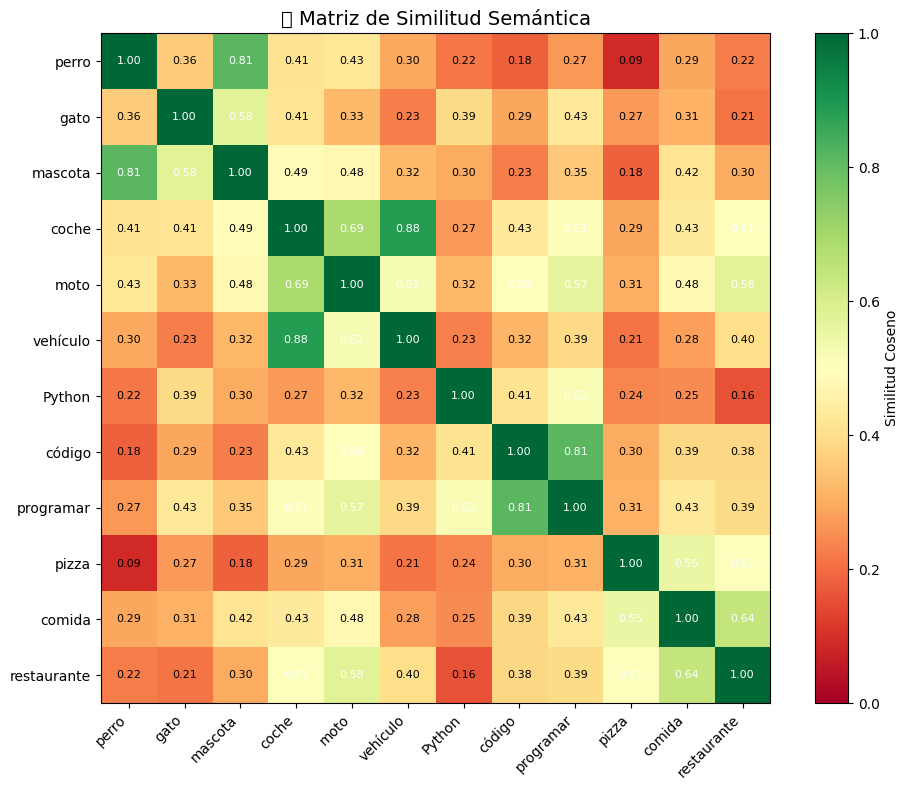


💡 OBSERVA:
   - La diagonal siempre es 1.0 (palabra consigo misma)
   - Los bloques verdes muestran palabras relacionadas
   - 'mascota' tiene alta similitud con 'perro' y 'gato'


In [14]:
# 🎨 Matriz de similitudes (Heatmap)

palabras_matriz = [
    "perro", "gato", "mascota",  # Animales/mascotas
    "coche", "moto", "vehículo",  # Transporte
    "Python", "código", "programar",  # Programación
    "pizza", "comida", "restaurante"  # Comida
]

# Generar embeddings
embeddings_matriz = modelo_embeddings.encode(palabras_matriz)

# Calcular matriz de similitud
matriz_sim = cosine_similarity(embeddings_matriz)

# Visualizar
plt.figure(figsize=(10, 8))
plt.imshow(matriz_sim, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(label='Similitud Coseno')

# Etiquetas
plt.xticks(range(len(palabras_matriz)), palabras_matriz, rotation=45, ha='right')
plt.yticks(range(len(palabras_matriz)), palabras_matriz)

# Añadir valores en las celdas
for i in range(len(palabras_matriz)):
    for j in range(len(palabras_matriz)):
        color = 'white' if matriz_sim[i,j] > 0.5 else 'black'
        plt.text(j, i, f'{matriz_sim[i,j]:.2f}', ha='center', va='center', 
                 color=color, fontsize=8)

plt.title('🎨 Matriz de Similitud Semántica', fontsize=14)
plt.tight_layout()
plt.show()

print("\n💡 OBSERVA:")
print("   - La diagonal siempre es 1.0 (palabra consigo misma)")
print("   - Los bloques verdes muestran palabras relacionadas")
print("   - 'mascota' tiene alta similitud con 'perro' y 'gato'")

## 2.4 Mini buscador semántico

Una aplicación práctica de embeddings: un **buscador que entiende el significado**.

A diferencia de buscar palabras exactas (como Ctrl+F), este buscador encuentra **documentos semánticamente similares** a tu consulta.

In [19]:
# 🔍 Mini Buscador Semántico

# Base de datos de documentos de ejemplo
documentos = [
    "El gato duerme tranquilamente en el sofá del salón",
    "Mi perro ladra cada vez que pasa el cartero por la puerta",
    "Python es un lenguaje de programación muy popular para data science",
    "El coche eléctrico contamina menos que los vehículos de gasolina",
    "La pizza italiana lleva tomate, mozzarella y albahaca fresca",
    "El machine learning permite a las máquinas aprender de datos",
    "Los pájaros migran hacia el sur cuando llega el invierno",
    "JavaScript se usa principalmente para desarrollo web frontend",
    "El tren de alta velocidad conecta Madrid con Barcelona en 2 horas",
    "La inteligencia artificial está transformando muchas industrias"
]

# Pre-calcular embeddings de todos los documentos
print("🔄 Indexando documentos...")
embeddings_docs = modelo_embeddings.encode(documentos)
print(f"✅ {len(documentos)} documentos indexados\n")

# Función de búsqueda
def buscar(consulta, top_k=3):
    # Embedding de la consulta
    emb_consulta = modelo_embeddings.encode(consulta)
    
    # Calcular similitudes
    similitudes = cosine_similarity([emb_consulta], embeddings_docs)[0]
    
    # Ordenar por similitud
    indices_ordenados = similitudes.argsort()[::-1][:top_k]
    
    print(f"🔍 Búsqueda: '{consulta}'")
    print("=" * 60)
    print()
    
    for i, idx in enumerate(indices_ordenados, 1):
        sim = similitudes[idx]
        doc = documentos[idx]
        barra = "█" * int(sim * 20)
        print(f"#{i} Similitud: {sim:.3f} {barra}")
        print(f"   📄 {doc}")
        print()

# Ejemplos de búsqueda
buscar("animales domésticos")

🔄 Indexando documentos...
✅ 10 documentos indexados

🔍 Búsqueda: 'animales domésticos'

#1 Similitud: 0.545 ██████████
   📄 Mi perro ladra cada vez que pasa el cartero por la puerta

#2 Similitud: 0.204 ████
   📄 Los pájaros migran hacia el sur cuando llega el invierno

#3 Similitud: 0.143 ██
   📄 El gato duerme tranquilamente en el sofá del salón



In [20]:
# Prueba con otras consultas
buscar("desarrollo de software")

🔍 Búsqueda: 'desarrollo de software'

#1 Similitud: 0.328 ██████
   📄 La inteligencia artificial está transformando muchas industrias

#2 Similitud: 0.306 ██████
   📄 Python es un lenguaje de programación muy popular para data science

#3 Similitud: 0.274 █████
   📄 El machine learning permite a las máquinas aprender de datos



In [21]:
# 🎮 Buscador interactivo

busqueda_input = Text(
    value='',
    placeholder='Escribe tu búsqueda...',
    description='Buscar:',
    layout=Layout(width='500px')
)

buscar_btn = Button(
    description='🔍 Buscar',
    button_style='primary',
    layout=Layout(width='150px')
)

output_busqueda = widgets.Output()

def ejecutar_busqueda(b):
    with output_busqueda:
        output_busqueda.clear_output()
        consulta = busqueda_input.value.strip()
        if consulta:
            buscar(consulta)
        else:
            print("⚠️ Escribe algo para buscar")

buscar_btn.on_click(ejecutar_busqueda)

print("📚 Base de datos de documentos:")
for i, doc in enumerate(documentos, 1):
    print(f"   {i}. {doc[:50]}...")
print()

display(VBox([busqueda_input, buscar_btn, output_busqueda]))

📚 Base de datos de documentos:
   1. El gato duerme tranquilamente en el sofá del salón...
   2. Mi perro ladra cada vez que pasa el cartero por la...
   3. Python es un lenguaje de programación muy popular ...
   4. El coche eléctrico contamina menos que los vehícul...
   5. La pizza italiana lleva tomate, mozzarella y albah...
   6. El machine learning permite a las máquinas aprende...
   7. Los pájaros migran hacia el sur cuando llega el in...
   8. JavaScript se usa principalmente para desarrollo w...
   9. El tren de alta velocidad conecta Madrid con Barce...
   10. La inteligencia artificial está transformando much...



---
# 🏪 3. MODELOS DE EMBEDDINGS

## 3.1 Proveedores principales

Existen múltiples proveedores de modelos de embeddings. Cada uno tiene sus ventajas:

### 🔷 OpenAI
- **Modelo**: `text-embedding-3-small`, `text-embedding-3-large`
- **Dimensiones**: 1536 / 3072
- **Precio**: $0.00002 / 1K tokens (small)
- **Ventajas**: Alta calidad, API sencilla

### 🔷 Google (Gemini)
- **Modelo**: `text-embedding-004`
- **Dimensiones**: 768
- **Precio**: **GRATIS** hasta límite
- **Ventajas**: Gratis, multilingüe

### 🔷 Cohere
- **Modelo**: `embed-multilingual-v3.0`
- **Dimensiones**: 1024
- **Precio**: $0.0001 / 1K tokens
- **Ventajas**: Excelente multilingüe

### 🔷 Voyage AI
- **Modelo**: `voyage-large-2`
- **Dimensiones**: 1536
- **Precio**: $0.00012 / 1K tokens
- **Ventajas**: Máxima calidad en retrieval

## 3.2 Modelos Open Source (GRATIS)

Hay excelentes opciones **100% gratuitas** que puedes ejecutar localmente:

### 🤗 HuggingFace / Sentence Transformers

| Modelo | Dimensiones | Idiomas | Tamaño | Uso ideal |
|--------|-------------|---------|--------|------------|
| `all-MiniLM-L6-v2` | 384 | EN | 80MB | Rápido, general |
| `all-mpnet-base-v2` | 768 | EN | 420MB | Alta calidad EN |
| `paraphrase-multilingual-MiniLM-L12-v2` | 384 | 50+ | 470MB | **Multilingüe** |
| `multilingual-e5-large` | 1024 | 100+ | 2.2GB | Máxima calidad multilingüe |

### 🦙 Ollama (Local)
- `nomic-embed-text` - 768 dim, muy bueno
- `mxbai-embed-large` - 1024 dim, alta calidad

## 3.3 Tabla comparativa completa

| Modelo | Proveedor | Dim. | Idiomas | Coste/1M tokens | Calidad MTEB |
|--------|-----------|------|---------|-----------------|-------------|
| `text-embedding-3-large` | OpenAI | 3072 | Multi | $0.13 | ⭐⭐⭐⭐⭐ |
| `text-embedding-3-small` | OpenAI | 1536 | Multi | $0.02 | ⭐⭐⭐⭐ |
| `text-embedding-004` | Google | 768 | Multi | **GRATIS** | ⭐⭐⭐⭐ |
| `embed-multilingual-v3` | Cohere | 1024 | 100+ | $0.10 | ⭐⭐⭐⭐⭐ |
| `voyage-large-2` | Voyage | 1536 | Multi | $0.12 | ⭐⭐⭐⭐⭐ |
| `multilingual-e5-large` | HuggingFace | 1024 | 100+ | **GRATIS** | ⭐⭐⭐⭐ |
| `all-MiniLM-L6-v2` | HuggingFace | 384 | EN | **GRATIS** | ⭐⭐⭐ |

*MTEB = Massive Text Embedding Benchmark*

## 3.4 Ejercicio: ¿Qué modelo para cada caso?

Basándote en la tabla anterior, elige el mejor modelo para cada escenario:

| Escenario | Tu elección | Por qué |
|-----------|-------------|----------|
| Startup sin presupuesto, solo español | | |
| Empresa con budget, máxima calidad | | |
| Aplicación offline, sin internet | | |
| Prototipo rápido, cualquier idioma | | |

In [22]:
# 💡 Respuestas sugeridas (ejecuta para ver)

respuestas = """
📋 RESPUESTAS SUGERIDAS:

1. Startup sin presupuesto, solo español:
   → paraphrase-multilingual-MiniLM-L12-v2 (HuggingFace)
   ✅ Gratis, buen español, ligero

2. Empresa con budget, máxima calidad:
   → text-embedding-3-large (OpenAI) o voyage-large-2
   ✅ Máxima calidad en benchmarks

3. Aplicación offline, sin internet:
   → multilingual-e5-large (HuggingFace) o nomic-embed (Ollama)
   ✅ Se ejecuta 100% local

4. Prototipo rápido, cualquier idioma:
   → text-embedding-004 (Google Gemini)
   ✅ Gratis, API sencilla, multilingüe
"""

print(respuestas)


📋 RESPUESTAS SUGERIDAS:

1. Startup sin presupuesto, solo español:
   → paraphrase-multilingual-MiniLM-L12-v2 (HuggingFace)
   ✅ Gratis, buen español, ligero

2. Empresa con budget, máxima calidad:
   → text-embedding-3-large (OpenAI) o voyage-large-2
   ✅ Máxima calidad en benchmarks

3. Aplicación offline, sin internet:
   → multilingual-e5-large (HuggingFace) o nomic-embed (Ollama)
   ✅ Se ejecuta 100% local

4. Prototipo rápido, cualquier idioma:
   → text-embedding-004 (Google Gemini)
   ✅ Gratis, API sencilla, multilingüe



---
# 🎫 4. TOKENS: La moneda del mundo LLM

## 4.1 ¿Qué es un token?

Un **token** NO es lo mismo que una palabra. Es la unidad mínima que procesa un LLM.

### 🔍 Ejemplos de tokenización:

```
"Hola"           → ["Hola"]                    (1 token)
"inteligencia"   → ["int", "elig", "encia"]    (3 tokens)
"ChatGPT"        → ["Chat", "G", "PT"]         (3 tokens)
"🚀"             → ["\xf0\x9f\x9a\x80"]        (1-4 tokens)
```

### 🧩 ¿Por qué tokens y no palabras?

1. **Vocabulario limitado**: Un modelo no puede memorizar todas las palabras posibles
2. **Subpalabras**: Permite manejar palabras nuevas/raras descomponiéndolas
3. **Multilingüe**: Funciona para cualquier idioma
4. **Eficiencia**: Balance entre vocabulario y longitud de secuencia

### 📊 Métodos de tokenización populares:

| Método | Usado por | Características |
|--------|-----------|------------------|
| **BPE** (Byte Pair Encoding) | GPT, Llama | Aprende pares frecuentes |
| **WordPiece** | BERT, Gemini | Similar a BPE, usado por Google |
| **SentencePiece** | T5, Llama | Independiente del idioma |

## 4.2 Tipos de tokens

Cuando usas un LLM, hay **diferentes tipos** de tokens que afectan al coste:

### 📥 Input tokens (Prompt)
- Lo que TÚ envías al modelo
- Incluye: instrucciones, contexto, preguntas
- Generalmente más baratos

### 📤 Output tokens (Completion)
- Lo que el modelo GENERA
- La respuesta que recibes
- Generalmente más caros (2-4x)

### 🧠 Reasoning tokens (Nuevo en 2024-2025)
- Tokens de "pensamiento interno" (o1, DeepSeek R1)
- No siempre visibles al usuario
- Se cobran aparte

```
┌────────────────────────────────────────┐
│           PETICIÓN A UN LLM            │
├────────────────────────────────────────┤
│                                        │
│  📥 INPUT (tu prompt):                 │
│  "Explica qué es Python"              │
│  → ~5 tokens × $0.001/1K = $0.000005  │
│                                        │
│  🧠 REASONING (interno):               │
│  [pensamiento oculto del modelo...]    │
│  → ~50 tokens × $0.002/1K = $0.0001   │
│                                        │
│  📤 OUTPUT (respuesta):                │
│  "Python es un lenguaje de..."        │
│  → ~100 tokens × $0.003/1K = $0.0003  │
│                                        │
│  💰 COSTE TOTAL: ~$0.0004              │
└────────────────────────────────────────┘
```

## 4.3 Contador de tokens interactivo

Vamos a ver cómo se tokeniza texto real usando **tiktoken** (tokenizador de OpenAI, gratuito y offline).

In [23]:
# 🎫 Cargar tokenizador

if TIKTOKEN_AVAILABLE:
    # Usamos el tokenizador de GPT-4 (cl100k_base)
    tokenizer = tiktoken.get_encoding("cl100k_base")
    print("✅ Tokenizador cargado: cl100k_base (usado por GPT-3.5/4)")
else:
    print("❌ tiktoken no disponible. Instala con: pip install tiktoken")

✅ Tokenizador cargado: cl100k_base (usado por GPT-3.5/4)


In [24]:
# 📊 Visualizar tokenización de un texto

def visualizar_tokens(texto):
    """Muestra cómo se tokeniza un texto"""
    tokens = tokenizer.encode(texto)
    
    print(f"📝 Texto: '{texto}'")
    print(f"📊 Número de tokens: {len(tokens)}")
    print(f"📐 Caracteres: {len(texto)}")
    print(f"📈 Ratio tokens/caracteres: {len(tokens)/len(texto):.3f}")
    print()
    print("🔍 Tokens individuales:")
    
    for i, token_id in enumerate(tokens):
        token_text = tokenizer.decode([token_id])
        # Mostrar espacios de forma visible
        display_text = token_text.replace(' ', '␣')
        print(f"   [{i+1}] ID={token_id:6d} → '{display_text}'")

# Ejemplos
visualizar_tokens("Hola mundo")

📝 Texto: 'Hola mundo'
📊 Número de tokens: 2
📐 Caracteres: 10
📈 Ratio tokens/caracteres: 0.200

🔍 Tokens individuales:
   [1] ID= 69112 → 'Hola'
   [2] ID= 29452 → '␣mundo'


In [25]:
# 🔍 Comparar tokenización de diferentes textos

textos_ejemplo = [
    "Hello world",
    "Hola mundo",
    "inteligencia artificial",
    "artificial intelligence",
    "ChatGPT es genial",
    "🚀🎉🔥",
    "12345",
    "supercalifragilistico"
]

print("📊 COMPARATIVA DE TOKENIZACIÓN")
print("=" * 70)
print(f"{'Texto':<35} {'Chars':>8} {'Tokens':>8} {'Ratio':>8}")
print("-" * 70)

for texto in textos_ejemplo:
    tokens = tokenizer.encode(texto)
    ratio = len(tokens) / len(texto) if len(texto) > 0 else 0
    print(f"{texto:<35} {len(texto):>8} {len(tokens):>8} {ratio:>8.3f}")

print()
print("💡 OBSERVA:")
print("   - Palabras comunes en inglés = menos tokens")
print("   - Palabras largas se dividen en subpalabras")
print("   - Emojis consumen varios tokens")
print("   - Números son relativamente eficientes")

📊 COMPARATIVA DE TOKENIZACIÓN
Texto                                  Chars   Tokens    Ratio
----------------------------------------------------------------------
Hello world                               11        2    0.182
Hola mundo                                10        2    0.200
inteligencia artificial                   23        4    0.174
artificial intelligence                   23        3    0.130
ChatGPT es genial                         17        6    0.353
🚀🎉🔥                                        3        9    3.000
12345                                      5        2    0.400
supercalifragilistico                     21        8    0.381

💡 OBSERVA:
   - Palabras comunes en inglés = menos tokens
   - Palabras largas se dividen en subpalabras
   - Emojis consumen varios tokens
   - Números son relativamente eficientes


In [26]:
# 🎮 Contador interactivo de tokens

texto_token_input = Textarea(
    value='Escribe aquí para contar tokens...',
    description='Texto:',
    layout=Layout(width='600px', height='100px')
)

contar_btn = Button(
    description='🔢 Contar Tokens',
    button_style='info',
    layout=Layout(width='200px')
)

output_tokens = widgets.Output()

def contar_tokens(b):
    with output_tokens:
        output_tokens.clear_output()
        texto = texto_token_input.value
        
        if not texto.strip():
            print("⚠️ Escribe algo de texto")
            return
        
        tokens = tokenizer.encode(texto)
        palabras = len(texto.split())
        caracteres = len(texto)
        
        print("📊 ANÁLISIS DE TOKENS")
        print("=" * 40)
        print(f"📝 Palabras: {palabras}")
        print(f"📐 Caracteres: {caracteres}")
        print(f"🎫 Tokens: {len(tokens)}")
        print()
        print(f"📈 Ratio tokens/palabra: {len(tokens)/palabras:.2f}" if palabras > 0 else "")
        print()
        print("💰 COSTE ESTIMADO (GPT-4):")
        coste_input = (len(tokens) / 1000) * 0.03  # $0.03/1K input
        print(f"   Como INPUT: ${coste_input:.6f}")
        coste_output = (len(tokens) / 1000) * 0.06  # $0.06/1K output
        print(f"   Como OUTPUT: ${coste_output:.6f}")

contar_btn.on_click(contar_tokens)

display(VBox([texto_token_input, contar_btn, output_tokens]))

## 4.4 Regla práctica: 1 token ≈ 0.75 palabras

Para **estimaciones rápidas**, puedes usar esta regla:

```
┌────────────────────────────────────────┐
│     REGLAS DE APROXIMACIÓN             │
├────────────────────────────────────────┤
│                                        │
│  📝 INGLÉS:                            │
│     1 token ≈ 4 caracteres            │
│     1 token ≈ 0.75 palabras           │
│     100 palabras ≈ 133 tokens         │
│                                        │
│  📝 ESPAÑOL:                           │
│     1 token ≈ 3-3.5 caracteres        │
│     1 token ≈ 0.6-0.7 palabras        │
│     100 palabras ≈ 140-150 tokens     │
│                                        │
│  📖 REFERENCIAS:                       │
│     1 página A4 ≈ 500 palabras        │
│                  ≈ 650-750 tokens     │
│     1 libro (300 pág) ≈ 200K tokens   │
│                                        │
└────────────────────────────────────────┘
```

### ⚠️ Importante:
- El español suele necesitar **más tokens** que el inglés para el mismo contenido
- Código fuente puede ser muy variable
- Siempre verifica con el contador real para estimaciones de coste

---
# 💰 5. PRECIOS Y CALCULADORA DE COSTES

## 5.1 Cómo leen los precios los proveedores

Los precios de APIs de LLM se expresan normalmente en **$/1K tokens** o **$/1M tokens**.

### 📖 Cómo leer una tabla de precios:

```
┌─────────────────────────────────────────────────────────┐
│  GPT-4 Turbo                                            │
│  ──────────────────────────────────────────────         │
│  Input:  $0.01/1K tokens = $10/1M tokens                │
│  Output: $0.03/1K tokens = $30/1M tokens                │
│                                                         │
│  Ejemplo: Prompt de 500 tokens + Respuesta de 200       │
│           = (500 × $0.01/1000) + (200 × $0.03/1000)     │
│           = $0.005 + $0.006 = $0.011                    │
└─────────────────────────────────────────────────────────┘
```

### 📊 Tabla de precios (Marzo 2026):

| Proveedor | Modelo | Input ($/M tokens) | Output ($/M tokens) | Contexto Máx. (tokens) |
|-----------|--------|---------------------|----------------------|------------------------|
| OpenAI | GPT-4o | 2.50 | 10.00 | 128K |
| OpenAI | GPT-5 | 1.25 | 10.00 | 400K |
| OpenAI | GPT-5.2 Pro | 21.00 | 168.00 | 400K |
| Anthropic | Claude 3 Haiku | 0.25 | 1.25 | 200K |
| Anthropic | Claude 3.5 Haiku | 0.80 | 4.00 | 200K |
| Anthropic | Claude Haiku 4.5 | 1.00 | 5.00 | 200K |
| Anthropic | Claude Sonnet 4.5 | 3.00 | 15.00 | 1M |
| Anthropic | Claude Sonnet 4.6 | 3.00 | 15.00 | 1M |
| Anthropic | Claude Opus 4.5 | 5.00 | 25.00 | 200K |
| Anthropic | Claude Opus 4.6 | 5.00 | 25.00 | 1M |
| Google Gemini | Gemini 2.5 Flash | 0.30 | 2.50 | 1M+ |
| Google Gemini | Gemini 2.5 Pro | 1.25 | 10.00 | 1M+ |
| Google Gemini | Gemini 3.1 Pro Preview | 2.00 | 12.00 | 1M+ |
| Google Gemini | Gemini 3 Pro Preview | 2.00 | 12.00 | 1M+ |
| xAI Grok | Grok 3 Beta | 3.00 | 15.00 | 131K |
| xAI Grok | Grok 4 | 3.00 | 15.00 | 256K |
| xAI Grok | Grok 4.1 Fast | 0.20 | 0.50 | 2M |

## 5.2 Ejercicio: Cálculo manual de costes

**Escenario**: Tienes una app que procesa emails de clientes.

- Email promedio: 200 palabras ≈ 270 tokens (input)
- Respuesta generada: 100 palabras ≈ 135 tokens (output)
- Volumen: 1,000 emails/día

**Calcula el coste diario con GPT-4o y con GPT-4o-mini:**

In [33]:
# 💡 Solución del ejercicio

# Datos del escenario
tokens_input_por_email = 270
tokens_output_por_email = 135
emails_por_dia = 1000

# Totales diarios
total_input = tokens_input_por_email * emails_por_dia
total_output = tokens_output_por_email * emails_por_dia

print("📊 CÁLCULO DE COSTES DIARIOS")
print("=" * 60)
print(f"📧 Emails/día: {emails_por_dia:,}")
print(f"📥 Tokens input/día: {total_input:,}")
print(f"📤 Tokens output/día: {total_output:,}")
print()

# Catálogo completo de modelos ($/1M tokens)
modelos = {
    "OpenAI - GPT-4o": {"input": 2.50, "output": 10.00},
    "OpenAI - GPT-5": {"input": 1.25, "output": 10.00},
    "OpenAI - GPT-5.2 Pro": {"input": 21.00, "output": 168.00},
    "Anthropic - Claude 3 Haiku": {"input": 0.25, "output": 1.25},
    "Anthropic - Claude 3.5 Haiku": {"input": 0.80, "output": 4.00},
    "Anthropic - Claude Haiku 4.5": {"input": 1.00, "output": 5.00},
    "Anthropic - Claude Sonnet 4.5": {"input": 3.00, "output": 15.00},
    "Anthropic - Claude Sonnet 4.6": {"input": 3.00, "output": 15.00},
    "Anthropic - Claude Opus 4.5": {"input": 5.00, "output": 25.00},
    "Anthropic - Claude Opus 4.6": {"input": 5.00, "output": 25.00},
    "Google Gemini - Gemini 2.5 Flash": {"input": 0.30, "output": 2.50},
    "Google Gemini - Gemini 2.5 Pro": {"input": 1.25, "output": 10.00},
    "Google Gemini - Gemini 3.1 Pro Preview": {"input": 2.00, "output": 12.00},
    "Google Gemini - Gemini 3 Pro Preview": {"input": 2.00, "output": 12.00},
    "xAI Grok - Grok 3 Beta": {"input": 3.00, "output": 15.00},
    "xAI Grok - Grok 4": {"input": 3.00, "output": 15.00},
    "xAI Grok - Grok 4.1 Fast": {"input": 0.20, "output": 0.50},
}

resultados = []

for modelo, precios in modelos.items():
    coste_input = (total_input / 1_000_000) * precios["input"]
    coste_output = (total_output / 1_000_000) * precios["output"]
    coste_total = coste_input + coste_output

    resultados.append({
        "modelo": modelo,
        "input": coste_input,
        "output": coste_output,
        "total": coste_total,
    })

# Ordenar por coste total diario (más barato primero)
resultados = sorted(resultados, key=lambda x: x["total"])

print("💰 COSTE DIARIO POR MODELO (ordenado de menor a mayor)")
print("-" * 60)
for r in resultados:
    print(f"{r['modelo']}")
    print(f"   Input:  ${r['input']:.4f}")
    print(f"   Output: ${r['output']:.4f}")
    print(f"   TOTAL:  ${r['total']:.4f}/día")
    print(f"   MENSUAL: ${r['total'] * 30:.2f}")
    print()

# Ahorro respecto a GPT-4o
base = next(r for r in resultados if r["modelo"] == "OpenAI - GPT-4o")
mas_barato = resultados[0]
ahorro = ((base["total"] - mas_barato["total"]) / base["total"]) * 100

print("📌 RESUMEN")
print("=" * 60)
print(f"Modelo más barato: {mas_barato['modelo']} (${mas_barato['total']:.4f}/día)")
print(f"Referencia GPT-4o: ${base['total']:.4f}/día")
print(f"Ahorro vs GPT-4o: {ahorro:.1f}%")

📊 CÁLCULO DE COSTES DIARIOS
📧 Emails/día: 1,000
📥 Tokens input/día: 270,000
📤 Tokens output/día: 135,000

💰 COSTE DIARIO POR MODELO (ordenado de menor a mayor)
------------------------------------------------------------
xAI Grok - Grok 4.1 Fast
   Input:  $0.0540
   Output: $0.0675
   TOTAL:  $0.1215/día
   MENSUAL: $3.65

Anthropic - Claude 3 Haiku
   Input:  $0.0675
   Output: $0.1688
   TOTAL:  $0.2363/día
   MENSUAL: $7.09

Google Gemini - Gemini 2.5 Flash
   Input:  $0.0810
   Output: $0.3375
   TOTAL:  $0.4185/día
   MENSUAL: $12.56

Anthropic - Claude 3.5 Haiku
   Input:  $0.2160
   Output: $0.5400
   TOTAL:  $0.7560/día
   MENSUAL: $22.68

Anthropic - Claude Haiku 4.5
   Input:  $0.2700
   Output: $0.6750
   TOTAL:  $0.9450/día
   MENSUAL: $28.35

OpenAI - GPT-5
   Input:  $0.3375
   Output: $1.3500
   TOTAL:  $1.6875/día
   MENSUAL: $50.62

Google Gemini - Gemini 2.5 Pro
   Input:  $0.3375
   Output: $1.3500
   TOTAL:  $1.6875/día
   MENSUAL: $50.62

OpenAI - GPT-4o
   Input:

## 5.3 Widget calculadora interactiva

In [34]:
# 🧮 Calculadora de Costes Interactiva

# Modelos y precios ($/1M tokens)
modelos = {
    "OpenAI - GPT-4o": {"input": 2.50, "output": 10.00, "contexto": "128K"},
    "OpenAI - GPT-5": {"input": 1.25, "output": 10.00, "contexto": "400K"},
    "OpenAI - GPT-5.2 Pro": {"input": 21.00, "output": 168.00, "contexto": "400K"},
    "Anthropic - Claude 3 Haiku": {"input": 0.25, "output": 1.25, "contexto": "200K"},
    "Anthropic - Claude 3.5 Haiku": {"input": 0.80, "output": 4.00, "contexto": "200K"},
    "Anthropic - Claude Haiku 4.5": {"input": 1.00, "output": 5.00, "contexto": "200K"},
    "Anthropic - Claude Sonnet 4.5": {"input": 3.00, "output": 15.00, "contexto": "1M"},
    "Anthropic - Claude Sonnet 4.6": {"input": 3.00, "output": 15.00, "contexto": "1M"},
    "Anthropic - Claude Opus 4.5": {"input": 5.00, "output": 25.00, "contexto": "200K"},
    "Anthropic - Claude Opus 4.6": {"input": 5.00, "output": 25.00, "contexto": "1M"},
    "Google Gemini - Gemini 2.5 Flash": {"input": 0.30, "output": 2.50, "contexto": "1M+"},
    "Google Gemini - Gemini 2.5 Pro": {"input": 1.25, "output": 10.00, "contexto": "1M+"},
    "Google Gemini - Gemini 3.1 Pro Preview": {"input": 2.00, "output": 12.00, "contexto": "1M+"},
    "Google Gemini - Gemini 3 Pro Preview": {"input": 2.00, "output": 12.00, "contexto": "1M+"},
    "xAI Grok - Grok 3 Beta": {"input": 3.00, "output": 15.00, "contexto": "131K"},
    "xAI Grok - Grok 4": {"input": 3.00, "output": 15.00, "contexto": "256K"},
    "xAI Grok - Grok 4.1 Fast": {"input": 0.20, "output": 0.50, "contexto": "2M"},
}

# Widgets
modelo_dropdown = widgets.Dropdown(
    options=list(modelos.keys()),
    value="OpenAI - GPT-5",
    description='Modelo:',
    layout=Layout(width='500px')
)

input_tokens_slider = widgets.IntSlider(
    value=1000,
    min=0,
    max=100000,
    step=100,
    description='Input tokens:',
    layout=Layout(width='400px')
)

output_tokens_slider = widgets.IntSlider(
    value=500,
    min=0,
    max=50000,
    step=100,
    description='Output tokens:',
    layout=Layout(width='400px')
)

peticiones_slider = widgets.IntSlider(
    value=100,
    min=1,
    max=10000,
    step=10,
    description='Peticiones:',
    layout=Layout(width='400px')
)

output_calculadora = widgets.Output()

def calcular_coste(change):
    with output_calculadora:
        output_calculadora.clear_output()

        modelo = modelo_dropdown.value
        precios = modelos[modelo]

        input_tok = input_tokens_slider.value
        output_tok = output_tokens_slider.value
        peticiones = peticiones_slider.value

        # Calcular
        total_input = input_tok * peticiones
        total_output = output_tok * peticiones

        coste_input = (total_input / 1_000_000) * precios["input"]
        coste_output = (total_output / 1_000_000) * precios["output"]
        coste_total = coste_input + coste_output

        print(f"💻 Modelo: {modelo}")
        print(f"🧠 Contexto máx.: {precios['contexto']}")
        print(f"📊 Precios: ${precios['input']}/1M input, ${precios['output']}/1M output")
        print("=" * 60)
        print(f"📥 Input total: {total_input:,} tokens")
        print(f"📤 Output total: {total_output:,} tokens")
        print()
        print(f"💰 Coste input:  ${coste_input:.6f}")
        print(f"💰 Coste output: ${coste_output:.6f}")
        print(f"💰 COSTE TOTAL:  ${coste_total:.6f}")
        print()
        print(f"📅 Si esto es diario:")
        print(f"   Semanal:  ${coste_total * 7:.4f}")
        print(f"   Mensual:  ${coste_total * 30:.4f}")
        print(f"   Anual:    ${coste_total * 365:.2f}")

# Conectar eventos
modelo_dropdown.observe(calcular_coste, names='value')
input_tokens_slider.observe(calcular_coste, names='value')
output_tokens_slider.observe(calcular_coste, names='value')
peticiones_slider.observe(calcular_coste, names='value')

print("🧮 CALCULADORA DE COSTES LLM")
print("Ajusta los parámetros para ver el coste estimado:\n")

display(VBox([
    modelo_dropdown,
    input_tokens_slider,
    output_tokens_slider,
    peticiones_slider,
    output_calculadora
]))

# Calcular inicial
calcular_coste(None)

🧮 CALCULADORA DE COSTES LLM
Ajusta los parámetros para ver el coste estimado:



## 5.4 Comparativa de precios: 10 modelos top

C:\Users\fbata\AppData\Local\Temp\ipykernel_2596\1586358319.py:53: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fbata\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


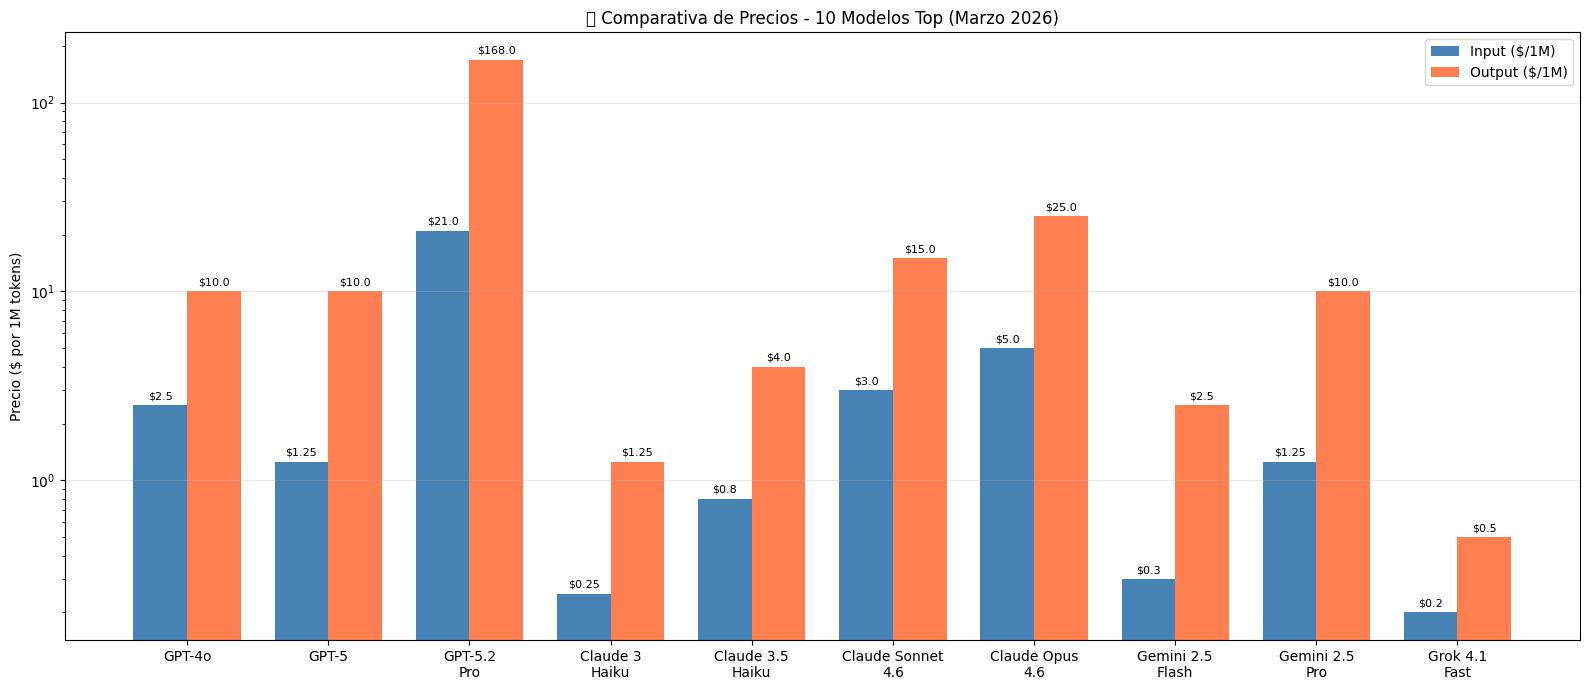


💡 OBSERVACIONES:
   - El eje Y está en escala logarítmica para comparar mejor modelos baratos y premium
   - GPT-5.2 Pro destaca como modelo premium de alto coste
   - Grok 4.1 Fast y Claude Haiku son opciones muy económicas


In [35]:
# 📊 Comparativa visual de precios

# Datos (10 modelos)
modelos_comp = [
    'GPT-4o',
    'GPT-5',
    'GPT-5.2\nPro',
    'Claude 3\nHaiku',
    'Claude 3.5\nHaiku',
    'Claude Sonnet\n4.6',
    'Claude Opus\n4.6',
    'Gemini 2.5\nFlash',
    'Gemini 2.5\nPro',
    'Grok 4.1\nFast'
]

precios_input = [2.50, 1.25, 21.00, 0.25, 0.80, 3.00, 5.00, 0.30, 1.25, 0.20]
precios_output = [10.00, 10.00, 168.00, 1.25, 4.00, 15.00, 25.00, 2.50, 10.00, 0.50]

x = np.arange(len(modelos_comp))
width = 0.38

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - width/2, precios_input, width, label='Input ($/1M)', color='steelblue')
bars2 = ax.bar(x + width/2, precios_output, width, label='Output ($/1M)', color='coral')

# Etiquetas
ax.set_ylabel('Precio ($ por 1M tokens)')
ax.set_title('💰 Comparativa de Precios - 10 Modelos Top (Marzo 2026)')
ax.set_xticks(x)
ax.set_xticklabels(modelos_comp)
ax.legend()
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)

# Añadir valores encima de las barras
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'${height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'${height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\n💡 OBSERVACIONES:")
print("   - El eje Y está en escala logarítmica para comparar mejor modelos baratos y premium")
print("   - GPT-5.2 Pro destaca como modelo premium de alto coste")
print("   - Grok 4.1 Fast y Claude Haiku son opciones muy económicas")

---
# 🎯 6. OPTIMIZA TUS TOKENS (AHORRA 💸)

## 6.1 Prompt largo vs. prompt corto

Menos tokens = menos coste. Pero hay un equilibrio entre brevedad y claridad.

In [30]:
# 📊 Comparación: Mismo objetivo, diferentes longitudes de prompt

prompt_largo = """
Eres un asistente de inteligencia artificial muy útil y amigable. Tu objetivo es ayudar 
a los usuarios de la mejor manera posible. Siempre debes ser respetuoso, profesional y 
proporcionar respuestas precisas y bien estructuradas.

Ahora, necesito que me ayudes con lo siguiente: Por favor, proporcióname un resumen 
conciso pero completo del siguiente texto, asegurándote de capturar los puntos principales 
y la idea central del mismo. El resumen debe ser fácil de entender y no debe exceder 
los 100 palabras aproximadamente:

Texto a resumir: La inteligencia artificial está transformando múltiples industrias.
"""

prompt_corto = """
Resume en 2 frases: La inteligencia artificial está transformando múltiples industrias.
"""

# Calcular tokens
tokens_largo = len(tokenizer.encode(prompt_largo))
tokens_corto = len(tokenizer.encode(prompt_corto))

print("📊 COMPARACIÓN DE PROMPTS")
print("=" * 50)
print()
print("📝 PROMPT LARGO:")
print(f"   Tokens: {tokens_largo}")
print(f"   Coste (GPT-4o): ${(tokens_largo/1_000_000)*2.50:.6f}")
print()
print("📝 PROMPT CORTO:")
print(f"   Tokens: {tokens_corto}")
print(f"   Coste (GPT-4o): ${(tokens_corto/1_000_000)*2.50:.6f}")
print()
print(f"💡 AHORRO: {((tokens_largo - tokens_corto)/tokens_largo)*100:.1f}% menos tokens")
print(f"   En 10,000 peticiones: ${((tokens_largo - tokens_corto)*10000/1_000_000)*2.50:.2f} ahorrados")

📊 COMPARACIÓN DE PROMPTS

📝 PROMPT LARGO:
   Tokens: 151
   Coste (GPT-4o): $0.000378

📝 PROMPT CORTO:
   Tokens: 21
   Coste (GPT-4o): $0.000052

💡 AHORRO: 86.1% menos tokens
   En 10,000 peticiones: $3.25 ahorrados


## 6.2 Recortar contexto innecesario

Cuando incluyes contexto (documentos, historial, etc.), elimina lo que no sea relevante.

In [31]:
# 🔪 Ejemplo: Recortar contexto innecesario

contexto_completo = """
Email #1 (hace 3 meses): Hola, quería preguntar sobre el horario de apertura...
Email #2 (hace 2 meses): Gracias por la información, muy útil...
Email #3 (hace 1 mes): Tengo una queja sobre un producto defectuoso...
Email #4 (hace 1 semana): Seguimiento de mi queja anterior, sigo esperando...
Email #5 (hoy): ¿Pueden darme una actualización del estado de mi reclamación?
"""

# Estrategias de recorte:

# 1. Solo últimos N emails
contexto_reciente = """
Email #4 (hace 1 semana): Seguimiento de mi queja anterior, sigo esperando...
Email #5 (hoy): ¿Pueden darme una actualización del estado de mi reclamación?
"""

# 2. Resumen del historial + último email
contexto_resumido = """
[Resumen: Cliente con queja de producto desde hace 1 mes, esperando resolución]
Email actual: ¿Pueden darme una actualización del estado de mi reclamación?
"""

tokens_completo = len(tokenizer.encode(contexto_completo))
tokens_reciente = len(tokenizer.encode(contexto_reciente))
tokens_resumido = len(tokenizer.encode(contexto_resumido))

print("📊 ESTRATEGIAS DE RECORTE DE CONTEXTO")
print("=" * 50)
print(f"\n📄 Contexto completo: {tokens_completo} tokens")
print(f"📄 Solo recientes:    {tokens_reciente} tokens ({100-tokens_reciente*100//tokens_completo}% menos)")
print(f"📄 Con resumen:       {tokens_resumido} tokens ({100-tokens_resumido*100//tokens_completo}% menos)")
print()
print("💡 CONSEJOS:")
print("   - Limita el historial a los últimos N mensajes relevantes")
print("   - Usa resúmenes para contexto antiguo")
print("   - Elimina saludos, firmas y contenido repetitivo")

📊 ESTRATEGIAS DE RECORTE DE CONTEXTO

📄 Contexto completo: 117 tokens
📄 Solo recientes:    49 tokens (59% menos)
📄 Con resumen:       42 tokens (65% menos)

💡 CONSEJOS:
   - Limita el historial a los últimos N mensajes relevantes
   - Usa resúmenes para contexto antiguo
   - Elimina saludos, firmas y contenido repetitivo


## 6.3 Limitar max_tokens en output

Puedes controlar cuántos tokens genera el modelo con el parámetro `max_tokens`.

In [32]:
# ⚙️ Impacto de max_tokens

print("💡 CÓMO USAR max_tokens")
print("=" * 50)
print("""
Cuando llamas a una API de LLM, puedes limitar la respuesta:

✅ EJEMPLO (Python con OpenAI):

```python
response = client.chat.completions.create(
    model="gpt-5",
    messages=[{"role": "user", "content": "Explica Python"}],
    max_tokens=100  # ← Limita la respuesta
)
```

📊 IMPACTO EN COSTES (ejemplo con GPT-5 output = $10/M):

┌─────────────────────────────────────────────┐
│  Sin límite:   ~500 tokens output = $0.005 │
│  max_tokens=100: 100 tokens output = $0.001│
│  AHORRO: 80%                                │
└─────────────────────────────────────────────┘

⚠️ CUIDADO:
- Si el límite es muy bajo, la respuesta se cortará
- Ajusta según la tarea (resumen corto vs explicación larga)
""")

💡 CÓMO USAR max_tokens

Cuando llamas a una API de LLM, puedes limitar la respuesta:

✅ EJEMPLO (Python con OpenAI):

```python
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Explica Python"}],
    max_tokens=100  # ← Limita la respuesta
)
```

📊 IMPACTO EN COSTES:

┌─────────────────────────────────────────────┐
│  Sin límite:   ~500 tokens output = $0.005  │
│  max_tokens=100: 100 tokens output = $0.001 │
│  AHORRO: 80%                                │
└─────────────────────────────────────────────┘

⚠️ CUIDADO:
- Si el límite es muy bajo, la respuesta se cortará
- Ajusta según la tarea (resumen corto vs explicación larga)



## 6.4 Ejercicio: Optimiza este prompt

El siguiente prompt es ineficiente. Tu objetivo es reescribirlo para **reducir tokens** sin perder claridad.

In [ ]:
# 🎯 EJERCICIO: Optimiza este prompt

prompt_ineficiente = """
Hola, espero que estés bien. Soy un desarrollador de software y estoy trabajando en un 
proyecto muy interesante. Me gustaría pedirte un favor si no es mucha molestia. Verás, 
necesito que me ayudes a escribir una función en el lenguaje de programación Python que 
sea capaz de realizar la siguiente tarea específica: tomar una lista de números enteros 
como parámetro de entrada y devolver solamente aquellos números que sean pares, es decir, 
que sean divisibles por 2 sin dejar resto. La función debe ser eficiente, bien documentada 
con comentarios explicativos, y seguir las mejores prácticas de programación en Python. 
Además, si pudieras incluir algunos ejemplos de uso de la función para que quede más claro 
cómo utilizarla, te lo agradecería enormemente. Muchas gracias de antemano por tu ayuda.
"""

tokens_original = len(tokenizer.encode(prompt_ineficiente))
coste_gpt5_input = (tokens_original / 1_000_000) * 1.25
print(f"📝 Prompt original: {tokens_original} tokens")
print(f"💰 Coste estimado input con GPT-5: ${coste_gpt5_input:.6f}")
print()
print("🎯 TU TAREA: Reescribe este prompt reduciendo tokens al máximo")
print("   Mantén la misma funcionalidad solicitada")
print()
print("💡 PISTAS:")
print("   - Elimina saludos y despedidas")
print("   - Quita explicaciones obvias")
print("   - Sé directo y conciso")
print("   - Usa términos técnicos precisos")

In [ ]:
# ✅ SOLUCIÓN PROPUESTA

prompt_optimizado = """
Escribe una función Python que filtre números pares de una lista. 
Incluye docstring y un ejemplo de uso.
"""

tokens_optimizado = len(tokenizer.encode(prompt_optimizado))

print("📊 COMPARACIÓN:")
print("=" * 50)
print(f"❌ Original:   {tokens_original} tokens")
print(f"✅ Optimizado: {tokens_optimizado} tokens")
print()
ahorro_pct = ((tokens_original - tokens_optimizado) / tokens_original) * 100
print(f"💰 AHORRO: {ahorro_pct:.1f}% menos tokens")
print()
print("📝 Prompt optimizado:")
print(prompt_optimizado)
print()
print("💡 El modelo entiende perfectamente la tarea con mucho menos texto.")

---
# 📋 RESUMEN Y CONCLUSIONES

## 🎓 Lo que has aprendido

### ⭐ Embeddings
- Son **vectores numéricos** que representan el **significado** del texto
- Permiten **comparar** textos por similitud semántica
- Aplicaciones: búsqueda semántica, clustering, detección de duplicados
- Opciones **gratuitas**: HuggingFace, Google Gemini (con límites)

### 🎫 Tokens
- No son palabras ni caracteres, son **subunidades** de texto
- **Regla práctica**: 1 token ≈ 0.75 palabras (en inglés)
- **Tipos**: input (más barato), output (más caro), reasoning (nuevo)

### 💰 Costes
- Se cobran por **$/1M tokens** (input y output separados)
- Hay modelos muy económicos y modelos premium con mayor coste
- Revisa siempre precios oficiales antes de producción

### 🎯 Optimización
- **Prompts concisos** = menos tokens = menos coste
- **Recorta contexto** innecesario
- Usa **max_tokens** para limitar output
- Elige el **modelo adecuado** para cada tarea

## 🔗 Recursos adicionales

- 📖 [Tokenizer interactivo de OpenAI](https://platform.openai.com/tokenizer)
- 📖 [HuggingFace Sentence Transformers](https://www.sbert.net/)
- 📖 [MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard) - Rankings de embeddings
- 📖 [Google AI Studio](https://makersuite.google.com/) - Embeddings gratuitos

---

✨ **¡Felicidades!** Has completado el Notebook 2. Ahora entiendes los fundamentos técnicos que hacen funcionar a los LLMs.